## STEP 1 — Libraries import

In [1]:
# STEP 1: Libraries import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# charts style
sns.set(style="whitegrid")

print("Libraries loaded")


Libraries loaded


## STEP 2 — Dataset load

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

In [3]:
print("Shape:", df.shape)

Shape: (9994, 21)


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## STEP 3 — Data cleaning

In [5]:
# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [6]:
# Check nulls
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:

# Remove duplicates if any
df = df.drop_duplicates()

In [8]:
print("Data cleaned")

Data cleaned


## STEP 4 — Line Chart (Sales over time)

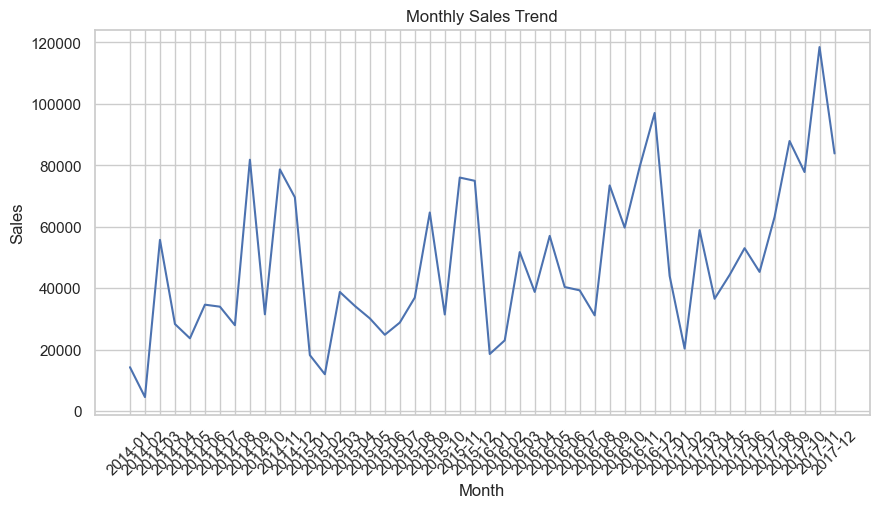

In [9]:
# Monthly sales
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()


Insights:

Sales show an overall increasing trend over time.

There are noticeable peaks in the last few months.

Seasonal fluctuations can be observed in some periods.

## STEP 5 — Bar Chart (Sales by Category)

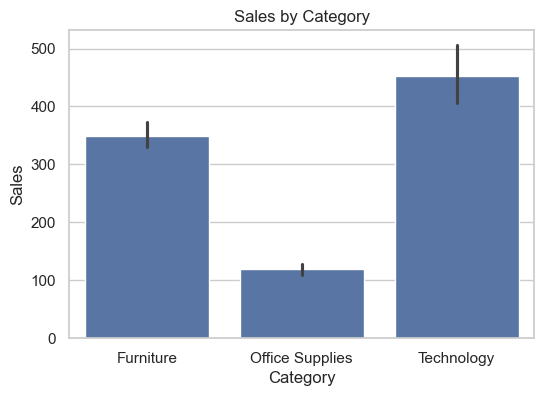

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x="Category", y="Sales", data=df)
plt.title("Sales by Category")
plt.show()


Insights:

Technology category has the highest sales.

Office Supplies has moderate sales.

Furniture category has the lowest sales among all categories.

## STEP 6 — Histogram (Sales distribution)

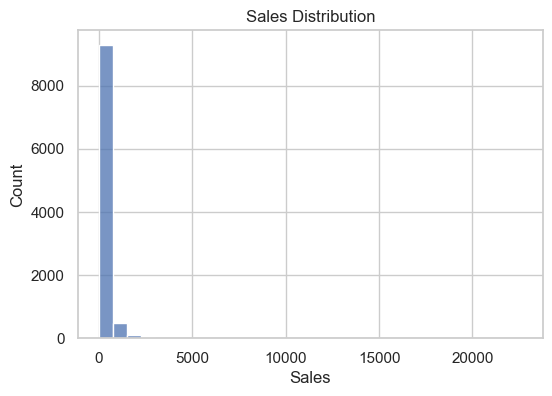

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df["Sales"], bins=30)
plt.title("Sales Distribution")
plt.show()


Insights:

Most orders have low sales values.

Only a few orders have very high sales values.

Sales distribution is right-skewed (positively skewed).

## STEP 7 — Scatter plot (Sales vs Profit)

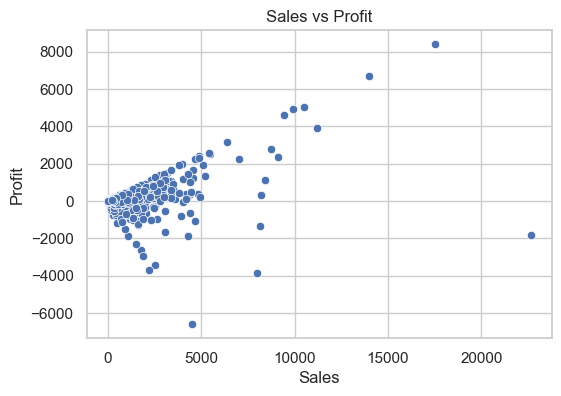

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.show()


Insights:

Higher sales generally lead to higher profit.

Some orders generate losses even with high sales.

The relationship between sales and profit is mostly positive but not perfect.

## STEP 8 — Heatmap (correlation)

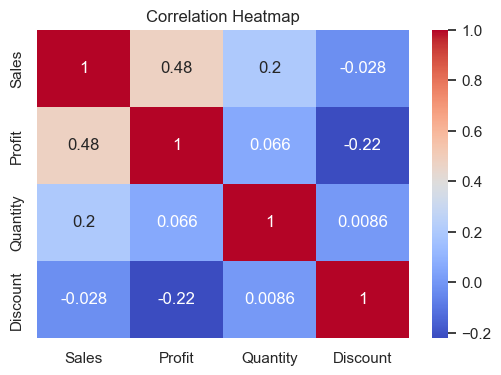

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["Sales","Profit","Quantity","Discount"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Insights:

Sales and Profit have a strong positive correlation.

Discount has a negative impact on Profit.

Quantity has a moderate correlation with Sales.

## STEP 9 — Pie chart (Category share)

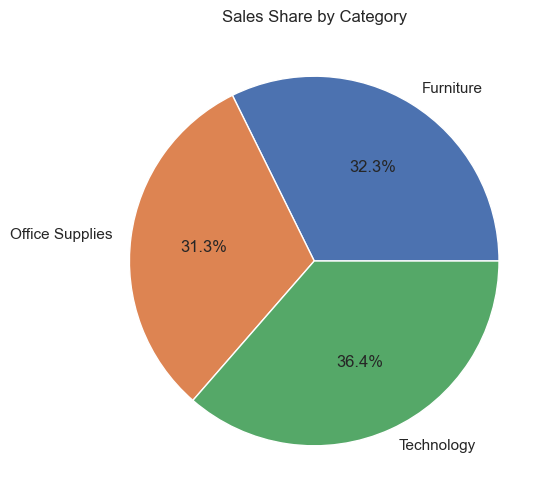

In [14]:
category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%")
plt.title("Sales Share by Category")
plt.show()


The Technology category has the highest share of total sales, indicating strong customer demand for technology products.

Office Supplies is the second largest contributor to total sales, showing consistent but moderate performance.

Furniture has the smallest share in total sales, which suggests relatively lower demand compared to other categories.

Overall, the sales distribution shows that Technology is the dominant revenue driver, while Furniture contributes the least.